In [40]:
# =============================================
# Résolution de l'Équation de Diffusion-Réaction Stationnaire
# -d²u/dx² + c(x)u = f avec x dans ]0 ,1[, avec
# f(x) = sin(πx), c(x) = constante ou variable
# et les conditions aux limites u(0) = α, u(1) = β
# ==============================================

In [41]:
# IMPORTATION DES LIBRAIRIES
# ==========================
import numpy as np
from sympy import symbols, Function, Eq, dsolve, exp
from sympy.abc import x, C
from scipy.sparse import dia_matrix
import sympy as sp
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
from scipy.linalg import norm

In [42]:
#%% MAILLAGE DU DOMAINE
# ==========================
NX = 10  # Nombre de points du maillage
x = np.linspace(0.0, 1, NX)  # Positions sur le domaine [0,1]
dx = 1 / (NX - 1)  # Pas de discrétisation

In [43]:
y = Function('y')
sym_x = symbols('x')

edo3 = Eq(-y(sym_x).diff(sym_x, 2) + 1*y(sym_x) + sym_x**2*exp(sym_x), 0)
solution_edo3 = dsolve(edo3, ics={y(0):0,y(1):0})
print(solution_edo3)


Eq(y(x), (x**3/6 - x**2/4 + x/4 - exp(2)/(-6 + 6*exp(2)))*exp(x) + exp(2)*exp(-x)/(-6 + 6*exp(2)))


In [44]:
# DÉFINITION DES FONCTIONS
# =========================
def func_f(x):
    return x**2 * np.exp(x)  # Fonction source f(x)

def func_c(x):
    return 1.0  # Coefficient c(x), constant dans cet exemple

def solution_exacte(x, alpha, beta):
    # return (x**3/6 - x**2/4 + x/4 - np.exp(2)/(-6 + 6*np.exp(2)))*np.exp(x) + np.exp(2)*np.exp(-x)/(-6 + 6*np.exp(2))
    return (x**3/6 - x**2/4 + x/4 - np.exp(2)/(-6 + 6*np.exp(2)))*np.exp(x) + np.exp(2)*np.exp(-x)/(-6 + 6*np.exp(2))

f = np.vectorize(func_f)
c = np.vectorize(func_c)

In [49]:
#%% CALCUL DE LA SOLUTION DISCRETE
# ================================
def U_discret(x, NX, dx, f, c):
    U = np.zeros((NX,))  # Initialisation du vecteur solution
    U[0] = 0  # Condition limite u(0) = alpha = 0
    U[-1] = 0  # Condition limite u(1) = beta = 0
    F = f(x)
    C = c(x)
    F = F[1:NX-1] 
    C = C[1:NX-1]

    val_diags = [-np.ones(NX - 2), 2 * np.ones(NX - 2), -np.ones(NX - 2)]  # Coefficients diagonaux
    positions = np.array([-1, 0, 1])  # Positions des diagonales
    A1 = dia_matrix((val_diags, positions), shape=(NX - 2, NX - 2))  # Matrice de Laplacien
    A2 = C * np.eye(NX-2, NX-2)
    A = (1/dx**2) * A1 + A2
    Uint = spsolve(A, F)  # Resolution du systeme lineaire
    U[1 : NX - 1] = Uint  # Insertion des valeurs interieures

    return U

c:\Users\bmd tech\anaconda3\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:214: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',


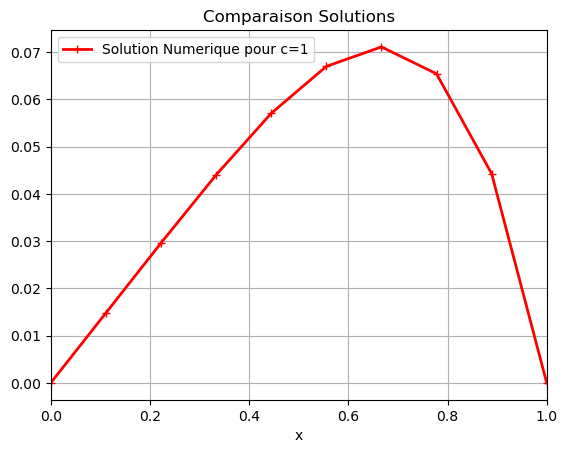

In [50]:
#%% AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
# =========================================================
U = U_discret(x, NX, dx, f, c)  # Solution numerique

fig, ax = plt.subplots(1)
ax.plot(x, U, "r-+", lw=2, label="Solution Numerique pour c=1")  # Courbe solution numerique
ax.set_xlabel("x")
# ax.set_ylabel("y")
ax.set_xlim([0, 1])
# ax.set_ylim([0, 0.11])
ax.set_title("Comparaison Solutions")
ax.legend()
ax.grid()
plt.show()